<a href="https://colab.research.google.com/github/aleksejalex/DYNR1cv_2026/blob/main/DYNR1cv_02_VI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DYNR1cv - Value iteration.

Prepared by: *Aleksej Gaj* ([email](mailto:aleksejalex@gmail.com))



In [1]:
%%capture
%pip install gymnasium
%pip install pygame

In [2]:
# imports:
import random
import numpy as np
#import gym  # old package, not maintained anymore
import gymnasium as gym
import matplotlib.pyplot as plt
from IPython import display

## 🛠️ Let's get familiar with our task!

### Setup - "the lake has frozen"...

Frozen lake involves crossing a frozen lake from start to goal without falling into any holes by walking over
the frozen lake.

The player may not always move in the intended direction due to the slippery nature of the
frozen lake.

[official documentation](https://gymnasium.farama.org/environments/toy_text/frozen_lake/)

[unoficial tutorial](https://aleksandarhaber.com/installation-and-getting-started-with-openai-gym-and-frozen-lake-environment-reinforcement-learning-tutorial/)



### Formalization:

**Actions**:

| Action  | Description |
|---------|-------------|
| `0`       | Move Left   |
| `1`       | Move Down   |
| `2`       | Move Right  |
| `3`       | Move Up     |

**States**:
`nrows`x`ncols` grid, player’s current position = `current_row * nrows + current_col` (where both the row and col start at 0).

**Starting state**:
 - always state `[0]` (ie. location [0, 0])

**Rewards**:

| Reward  | Description                       |
|---------|-----------------------------------|
| 0       | Frozen surface (Safe)             |
| 1       | Goal (Reach the goal)             |
| 0       | Hole (Fall into a hole)           |

**Terminal state(s)**:
 - goal (`G`) ... "win"
 - any hole (`H`) ... "lose"

**Is slippery?**
 - agent can the the action with p=1/3 and the "orthogonal" actions also with  p = 1/3 each

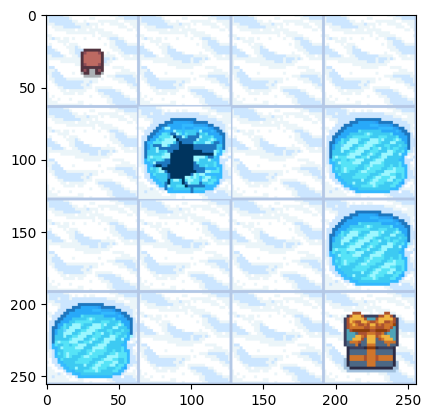

In [3]:
env = gym.make("FrozenLake-v1", map_name="4x4", render_mode="rgb_array", is_slippery=True)

state=env.reset()[0]
done=False

while not done:
    action=env.action_space.sample()
    new_state, reward, done, info, x = env.step(action)
    img=plt.imshow(env.render())
    display.display(plt.gcf())
    display.clear_output(wait=True)

### Define your custom map:

```
F = firm ice
H = hole in the ice
G = goal
S = starting location
```

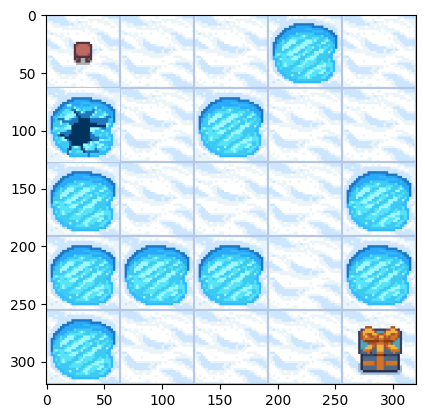

In [4]:
custom_map = [
    'SFFHF',
    'HFHFF',
    'HFFFH',
    'HHHFH',
    'HFFFG'
]

env = gym.make("FrozenLake-v1", desc=custom_map, render_mode="rgb_array", is_slippery=True)

state=env.reset()[0]
done=False

while not done:
    action=env.action_space.sample()
    new_state, reward, done, info, x = env.step(action)
    img=plt.imshow(env.render())
    display.display(plt.gcf())
    display.clear_output(wait=True)

How does the enviromnent 'look' like?

In [5]:
temp_s = 12
temp_a = 2
env.unwrapped.P[temp_s][temp_a]

[(0.33333333333333337, 17, 0, True),
 (0.3333333333333333, 13, 0, False),
 (0.33333333333333337, 7, 0, True)]

...which means that when in state `temp_s`, chosen action `temp_a` leads to 3 possible outcomes (three rows):
  - `0.3333...` is probability of such outcome ($=1$ when not slippery)
  - `17, 13, 7` are next states
  - `0.0` is reward on of current outcome
  - `False` means the game is not over yet

Now we have working environment to test and visualize the algorithm.

### VI - the code

Value function to remind:

$$
    V_{k+1}(s_t) = \max_{a \in A} \sum_{s_{t+1}\in S} p\left( s_{t+1}|s_t, a \right) \left[ R(s_{t+1}, s_t, a) + \gamma V_{k}(s_{t+1}) \right]   ,
$$
where:
 - $p\left( s_{t+1}|s_t, a \right)$ is model
 - whole sum on the right hand side is mean value of square bracket with prob. dist. $p$
 - $\gamma \in [0,1]$ is discont factor, which directly influences the rate and stability of convergence

Resulting policy is *optimal* ⇔ $ V^{\pi^{\text{opt}}}(s_t) \geq V^{\pi}_{k}(s_t) \quad \forall s, \: \forall \pi, \:  \forall k $

Iteration stops when
$$
|| V_{k+1} - V_{k}|| < \frac{\epsilon (1-\gamma)}{\gamma} \quad \forall s \in S
$$

In [6]:
def value_iteration(env, gamma=0.99, epsilon=1e-6):
    num_states = env.observation_space.n
    num_actions = env.action_space.n
    num_of_iter = 0   # counter for computing iterations

    # Initialize value function
    V = np.zeros(num_states)
    P = env.unwrapped.P  # more modern, instead of using directly 'env.P'

    while True:
        delta = 0
        num_of_iter = num_of_iter + 1
        for s in range(num_states):
            v = V[s]
            Q_s = np.zeros(num_actions)
            for a in range(num_actions):
                for prob, next_state, reward, done in P[s][a]:
                    Q_s[a] += prob * (reward + gamma * V[next_state]) # calculation for every action (expr. inside the summation)
            V[s] = np.max(Q_s) # max through actions
            delta = max(delta, abs(v - V[s]))  # the cycle through states ends with the greatest delta
        if delta < epsilon:
            break

    # Find optimal policy
    policy = np.zeros(num_states, dtype=np.int32)
    for s in range(num_states): # we go though all states...
        Q_s = np.zeros(num_actions)
        for a in range(num_actions):
            for prob, next_state, reward, done in P[s][a]:
                Q_s[a] += prob * (reward + gamma * V[next_state])
        policy[s] = np.argmax(Q_s) # ...and for each state we find optimal action

    return V, policy, num_of_iter

### VI - optimal policy

In [7]:
# define the environment
env = gym.make("FrozenLake-v1", map_name="4x4", render_mode="rgb_array", is_slippery=True)
#env = gym.make("FrozenLake-v1", desc=custom_map, render_mode="rgb_array", is_slippery=False)  # custom map, but NOT slippery!
# value iteration (implemented above)
optimal_V, optimal_policy, num_of_iter = value_iteration(env)

In [8]:
print("Optimal Value Function:")
print(optimal_V)
print("Optimal Policy:")
print(optimal_policy)
print(f"Number of iterations: {num_of_iter}.")

Optimal Value Function:
[0.54201404 0.49878743 0.47067727 0.45683193 0.5584404  0.
 0.35834012 0.         0.59179013 0.64307363 0.61520214 0.
 0.         0.74171617 0.86283528 0.        ]
Optimal Policy:
[0 3 3 3 0 0 0 0 3 1 0 0 0 2 1 0]
Number of iterations: 228.


try to adjust the `epsilon`. How many iterations are necesary?

try to play with `gamma`.

### VI - visualize (simulation)

In [9]:
# initialize the env
state=env.reset()[0]
done = False
total_reward = 0
total_steps = 0

In [10]:
optimal_policy

array([0, 3, 3, 3, 0, 0, 0, 0, 3, 1, 0, 0, 0, 2, 1, 0], dtype=int32)

Total reward received: 1.
Elf made 16 steps.


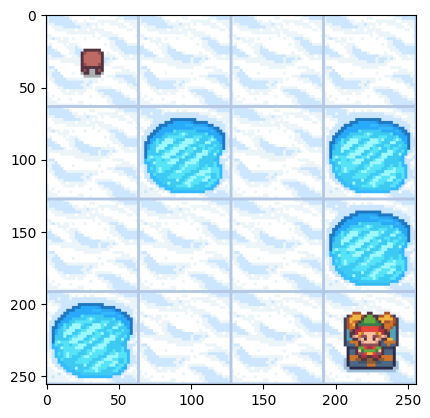

In [11]:
#in cycle: make action and show the situation
while not done:
    action = optimal_policy[state]
    new_state, reward, done, info, x = env.step(action)
    total_reward = total_reward+reward
    total_steps = total_steps+1

    img=plt.imshow(env.render())
    display.display(plt.gcf())
    display.clear_output(wait=True)

    state=new_state
print(f"Total reward received: {total_reward}.")
print(f"Elf made {total_steps} steps.")